In [3]:
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
#import cmasher as cmr
import matplotlib.colors as mcolors
import mplcursors

In [4]:
import IPython
notebook_name = "/".join(
        IPython.extract_module_locals()[1]["__vsc_ipynb_file__"].split("/")[-5:]
    )
print(notebook_name)

hgrup_vsun/USOS_shared/Plotting/For_F0AM_runs/precursor_plots.ipynb


In [79]:
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 28
mpl.rcParams['axes.xmargin'] = 0

# Set the font family to 'serif'
mpl.rcParams['font.family'] = 'serif'
# Specify preferred serif font (Computer Modern Roman is 'cmr10')
mpl.rcParams['font.serif'] = 'Lato' 
# Optionally, configure mathtext to use Computer Modern fonts as well
mpl.rcParams['mathtext.fontset'] = 'cm'
# Ensure minus signs are rendered correctly with CM fonts
mpl.rcParams['axes.unicode_minus'] = False

In [5]:
dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'

data_date = '7_19_2024'
run_number = '30'
chemical_mechanisms = ['GEOS-Chem','CRACMM','CB6r5h']

yaml_run_dirpath = dirpath + 'F0AM-4.4.2/Runs/USOS_' + data_date + '/Run' + run_number + '/'

ozone_yaml_geoschem_dirpath = yaml_run_dirpath + chemical_mechanisms[0] + '/' 
ozone_yaml_run_geoschem_full_filepath = ozone_yaml_geoschem_dirpath + 'USOS_' + data_date + '_' + chemical_mechanisms[0] +  '_Run' + run_number + '_ozone_production_output.yaml'

ozone_yaml_cracmm_dirpath = yaml_run_dirpath + chemical_mechanisms[1] + '/' 
ozone_yaml_run_cracmm_full_filepath = ozone_yaml_cracmm_dirpath + 'USOS_' + data_date + '_' +  chemical_mechanisms[1] + '_Run' + run_number + '_ozone_production_output.yaml'

ozone_yaml_cb6r5h_dirpath = yaml_run_dirpath + chemical_mechanisms[2] + '/' 
ozone_yaml_run_cb6r5h_full_filepath = ozone_yaml_cb6r5h_dirpath + 'USOS_' + data_date + '_' +  chemical_mechanisms[2] + '_Run' + run_number + '_ozone_production_output.yaml'

In [6]:
with open(ozone_yaml_run_geoschem_full_filepath, 'r') as f:
    ozone_yaml_geoschem = yaml.full_load(f)

with open(ozone_yaml_run_cracmm_full_filepath, 'r') as f:
    ozone_yaml_cracmm = yaml.full_load(f)

with open(ozone_yaml_run_cb6r5h_full_filepath, 'r') as f:
    ozone_yaml_cb6r5h = yaml.full_load(f)

In [165]:
# print(ozone_yaml_geoschem.keys())
# print(ozone_yaml_geoschem['RO2_NO_conversion_rxns'])

RO2_labels_geoschem = []

for rxn in ozone_yaml_geoschem['RO2_NO_conversion_rxns']:
    species = rxn.split('+NO')[0]
    RO2_labels_geoschem.append(species)

print(RO2_labels_geoschem)

['MO2', 'MCO3', 'ETO2', 'OTHRO2', 'A3O2', 'PO2', 'R7O2', 'R7N1', 'BUTO2', 'ACRO2', 'ACO3', 'ALK4O2', 'ALK4N1', 'R4O2', 'R4N1', 'ATO2', 'KO2', 'B3O2', 'PRN1', 'RCO3', 'KO2', 'GCO3', 'APINO2', 'PINO3', 'C96O2', 'BPINO2', 'BPINOO2', 'LIMO2', 'LIMKO2', 'LIMO3', 'PIO2', 'IHOO1', 'IHOO1', 'IHOO4', 'IHOO4', 'IHPOO1', 'IHPOO2', 'IHPOO3', 'ICHOO', 'ISOPNOO1', 'ISOPNOO2', 'IDHNDOO1', 'IDHNDOO2', 'IDHNBOO', 'INO2B', 'INO2D', 'IHPNBOO', 'IHPNDOO', 'C4HVP1', 'C4HVP2', 'MVKOHOO', 'MCROHOO', 'MACR1OO', 'ZRO2', 'ETOO', 'AROMRO2', 'AROMCO3', 'BZCO3', 'BENZO2']


In [166]:
df_geoschem_ro2 = pd.DataFrame({'RO2':RO2_labels_geoschem})
df_geoschem_ro2

,RO2
0,MO2
1,MCO3
2,ETO2
3,OTHRO2
4,A3O2
5,PO2
6,R7O2
7,R7N1
8,BUTO2
9,ACRO2


In [167]:
#Read CSV mapping the species to each VOC precursor
geoschem_cat_load = pd.read_csv(dirpath + 'Mechanism_info/geoschem_ro2_list.csv')
#Replace the 'Mix of...' species with 'Other' label, make all species without a category into 'Other'
geoschem_cat_load = geoschem_cat_load.replace(to_replace = geoschem_cat_load['General Precursor or Category'][13], value = 'Other')
geoschem_cat_load = geoschem_cat_load['General Precursor or Category'].fillna(value = 'Other')
print(geoschem_cat_load)

0     Methylperoxy radicals
1     Peroxyacetyl radicals
2                   Alkanes
3                     Other
4                   Alkanes
5                   Alkenes
6                   Alkanes
7                     Other
8                    Dienes
9                 Aldehydes
10                    Other
11                  Alkanes
12                  Alkanes
13                    Other
14                    Other
15                  Ketones
16                  Ketones
17                    Other
18                  Alkenes
19                    Other
20                  Ketones
21                    Other
22             Monoterpenes
23             Monoterpenes
24             Monoterpenes
25             Monoterpenes
26             Monoterpenes
27             Monoterpenes
28             Monoterpenes
29             Monoterpenes
30             Monoterpenes
31                 Isoprene
32                 Isoprene
33                 Isoprene
34                 Isoprene
35                 I

In [168]:
df_geoschem_ro2['Precursor'] = geoschem_cat_load
# df_geoschem['Rate'] = ozone_yaml_geoschem['RO2_NO_scaled_rates']
sum_total_voc_prod = np.sum(ozone_yaml_geoschem['RO2_NO_scaled_rates'],axis=0)
voc_fraction = (ozone_yaml_geoschem['RO2_NO_scaled_rates'] / sum_total_voc_prod)*100
df_geoschem_ro2['Fractional Contribution of VOC'] = [spec for spec in voc_fraction]

# #Make a new dataframe where all the contributions for each category is summed together
geoschem_precursor_sum = df_geoschem_ro2.groupby('Precursor')['Fractional Contribution of VOC'].sum()
df_geoschem_precursor_sum = geoschem_precursor_sum.to_frame()
df_geoschem_precursor_sum.index = df_geoschem_precursor_sum.index.str.replace('Monoterpenes', 'Terpenes')

colors_by_hex_geoschem = ['#f7879a', '#c20078', '#fe4b03', '#fcc006', '#548d44', '#017371', '#a2cffe', '#0485d1', '#b790d4', '#3d1c02', '#a8a495', '#070d0d']
df_geoschem_precursor_sum['colors'] = colors_by_hex_geoschem

frac_contribution_stack_geoschem = np.vstack(df_geoschem_precursor_sum['Fractional Contribution of VOC'].values)

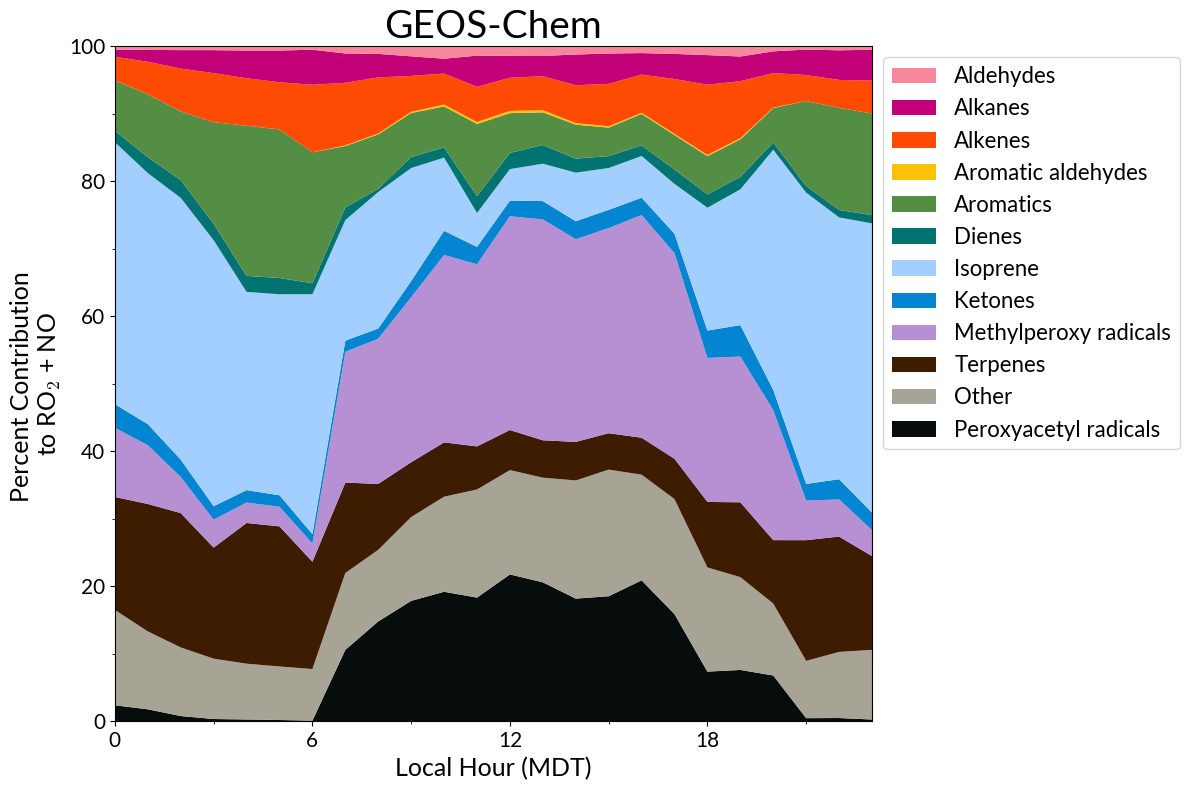

In [171]:
hour_range = np.arange(0,24,1)

fix, ax = plt.subplots(figsize=(12,8))

plt.stackplot(hour_range, *frac_contribution_stack_geoschem[::-1], colors=df_geoschem_precursor_sum['colors'][::-1], labels= df_geoschem_precursor_sum.index[::-1])
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], loc='upper left', bbox_to_anchor=(1,1))

plt.margins(x=0, y=0)
ax.xaxis.set_minor_locator(MultipleLocator(3))
ax.xaxis.set_major_locator(MultipleLocator(6))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.yaxis.set_major_locator(MultipleLocator(20))

plt.xlabel('Local Hour (MDT)')
plt.ylabel('Percent Contribution \nto RO$_2$ + NO')
plt.title('GEOS-Chem')
plt.tight_layout()
plt.savefig(dirpath + 'Plotting/For_F0AM_runs/plots/voc_precursor_ro2_no_GEOSChem.png', dpi =150, bbox_inches='tight')
plt.show()

---

## CRACMM

In [118]:
RO2_labels_cracmm = []
for rxn in ozone_yaml_cracmm['RO2_NO_conversion_rxns']:
    species = rxn.split(' + NO')[0]
    RO2_labels_cracmm.append(species)

print(RO2_labels_cracmm)

['ISOP', 'MO2', 'ETHP', 'HC3P', 'HC5P', 'ETEP', 'OLTP', 'OLIP', 'BENP', 'TOLP', 'XYLP', 'EBZP', 'APIP1', 'APIP2', 'APINP1', 'APINP2', 'LIMP1', 'LIMP2', 'LIMNP1', 'LIMNP2', 'ACO3', 'RCO3', 'ACTP', 'KETP', 'MACP', 'MCP', 'MVKP', 'UALP', 'BALP', 'BAL1', 'ORAP', 'BDE13P', 'FURANO2', 'SESQNRO2', 'SESQRO2', 'VROCP6ALKP', 'VROCP5ALKP', 'VROCP4ALKP', 'VROCP3ALKP', 'VROCP2ALKP', 'VROCP1ALKP', 'HC10P', 'VROCP6ALKP2', 'VROCP5ALKP2', 'VROCP4ALKP2', 'VROCP3ALKP2', 'VROCP2ALKP2', 'VROCP1ALKP2', 'HC10P2', 'VROCP6AROP', 'VROCP5AROP', 'NAPHP', 'STYP']


In [119]:
df_cracmm_ro2 = pd.DataFrame({'RO2':RO2_labels_cracmm})
df_cracmm_ro2

,RO2
0,ISOP
1,MO2
2,ETHP
3,HC3P
4,HC5P
5,ETEP
6,OLTP
7,OLIP
8,BENP
9,TOLP


In [120]:
#Read CSV mapping the species to each VOC precursor
cracmm_cat_load = pd.read_csv(dirpath + 'Mechanism_info/cracmm_ro2_list.csv')
cracmm_cat_load = cracmm_cat_load['General Precursor or Category'].fillna(value = 'Other')
print(cracmm_cat_load)

0                  Isoprene
1     Methylperoxy radicals
2                   Alkanes
3                   Alkanes
4                   Alkanes
5                   Alkenes
6                   Alkenes
7                   Alkenes
8                 Aromatics
9                 Aromatics
10                Aromatics
11                Aromatics
12                 Terpenes
13                 Terpenes
14                 Terpenes
15                 Terpenes
16                 Terpenes
17                 Terpenes
18                 Terpenes
19                 Terpenes
20    Peroxyacetyl radicals
21                    Other
22                  Ketones
23                  Ketones
24                Aldehydes
25                Aldehydes
26                  Ketones
27                Aldehydes
28       Aromatic aldehydes
29       Aromatic aldehydes
30              Acetic Acid
31                   Dienes
32                   Dienes
33                 Terpenes
34                 Terpenes
35                  

In [121]:
df_cracmm_ro2['Precursor'] = cracmm_cat_load
sum_total_voc_prod_cracmm = np.sum(ozone_yaml_cracmm['RO2_NO_scaled_rates'],axis=0)
voc_fraction_cracmm = (ozone_yaml_cracmm['RO2_NO_scaled_rates'] / sum_total_voc_prod_cracmm)*100
df_cracmm_ro2['Fractional Contribution of VOC'] = [spec for spec in voc_fraction_cracmm]

In [122]:
print(df_cracmm_ro2['Fractional Contribution of VOC'])

0     [5.189333450173291, 5.5682889498681405, 3.3330...
1     [3.8275252149435923, 2.559171333853515, 0.7328...
2     [0.6916804738736699, 0.7910672409826723, 0.619...
3     [0.7660245326096754, 0.9426482395697372, 0.780...
4     [0.4864669535571708, 0.8983102439777626, 0.916...
5     [0.3136317220878474, 0.4134024537077887, 0.368...
6     [1.0548982680055028, 1.2791646312347031, 1.058...
7     [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
8     [0.0034647827089341102, 0.000994862970403803, ...
9     [0.08020644400381705, 0.09646216138905073, 0.1...
10    [0.6680731024010043, 1.0058181714450494, 0.926...
11    [0.02213410946111843, 0.03449922589801092, 0.0...
12    [2.232098996384762, 2.3744485817585836, 1.6819...
13    [0.0225151917538035, 0.016855462010157328, 0.0...
14    [43.60242101303004, 43.78732659757827, 48.1538...
15    [0.028483784190398504, 0.01959632518596172, 0....
16    [1.9750913003882316, 2.1109080642137847, 1.503...
17    [0.05285650659964849, 0.03956044066101903,

In [128]:
cracmm_precursor_sum = df_cracmm_ro2.groupby('Precursor')['Fractional Contribution of VOC'].sum()
df_cracmm_precursor_sum = cracmm_precursor_sum.to_frame()
print(df_cracmm_precursor_sum)
df_cracmm_precursor_sum_species_order = ['Acetic Acid', 'Aldehydes', 'Alkanes', 'Alkenes', 'Aromatic aldehydes','Aromatics', 'Dienes', 'Isoprene', 'Ketones', 'Methylperoxy radicals','Terpenes', 'Other', 'Peroxyacetyl radicals']
df_cracmm_precursor_sum_rearranged = df_cracmm_precursor_sum.reindex(df_cracmm_precursor_sum_species_order)
print(df_cracmm_precursor_sum_rearranged)

                                          Fractional Contribution of VOC
Precursor                                                               
Acetic Acid            [0.002311920077001688, 0.0018608971903316604, ...
Aldehydes              [1.4894907238184878, 1.3081760579630382, 0.866...
Alkanes                [1.9793352744890116, 2.7684890875017647, 2.483...
Alkenes                [1.36852999009335, 1.6925670849424919, 1.42726...
Aromatic aldehydes     [0.01773026847662244, 0.015335508192843825, 0....
Aromatics              [0.7920888900777556, 1.1546236716232359, 1.087...
Dienes                 [0.5644905440559209, 0.6621126494143045, 0.532...
Isoprene               [5.189333450173291, 5.5682889498681405, 3.3330...
Ketones                [1.7437290580065936, 1.307838055959125, 0.7625...
Methylperoxy radicals  [3.8275252149435923, 2.559171333853515, 0.7328...
Other                  [0.1239313506900998, 0.07197497058502964, 0.02...
Peroxyacetyl radicals  [1.1572726491145102, 0.73762

In [129]:
colors_by_hex_cracmm = ['#ffcfdc', '#f7879a', '#c20078', '#fe4b03', '#fcc006', '#548d44', '#017371', '#a2cffe', '#0485d1', '#b790d4', '#3d1c02', '#a8a495', '#070d0d']
df_cracmm_precursor_sum_rearranged['colors'] = colors_by_hex_cracmm

frac_contribution_stack_cracmm = np.vstack(df_cracmm_precursor_sum_rearranged['Fractional Contribution of VOC'].values)

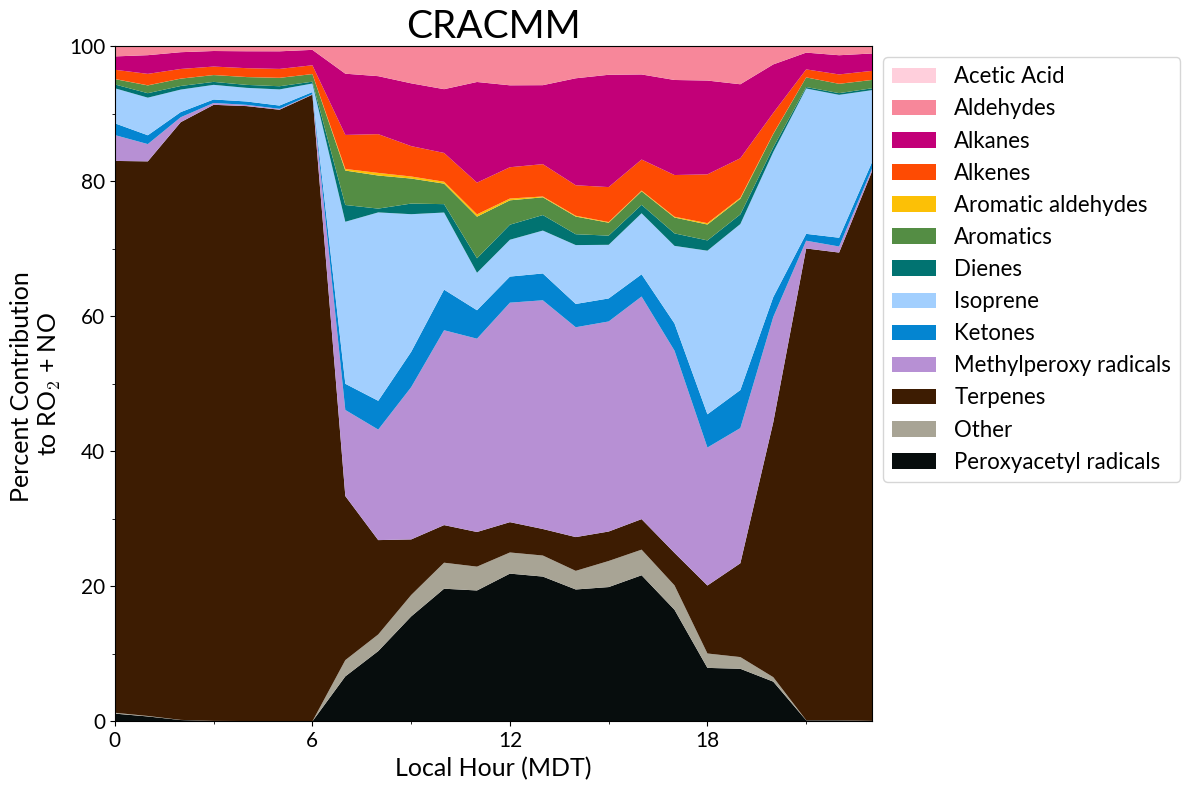

In [172]:
hour_range = np.arange(0,24,1)

fix, ax = plt.subplots(figsize=(12,8))

plt.stackplot(hour_range, *frac_contribution_stack_cracmm[::-1], colors=df_cracmm_precursor_sum_rearranged['colors'][::-1], labels=df_cracmm_precursor_sum_rearranged.index[::-1])
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], loc='upper left', bbox_to_anchor=(1,1))

plt.margins(x=0, y=0)
ax.xaxis.set_minor_locator(MultipleLocator(3))
ax.xaxis.set_major_locator(MultipleLocator(6))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.yaxis.set_major_locator(MultipleLocator(20))

plt.xlabel('Local Hour (MDT)')
plt.ylabel('Percent Contribution \nto RO$_2$ + NO')
plt.title('CRACMM')
plt.tight_layout()
plt.savefig(dirpath + 'Plotting/For_F0AM_runs/plots/voc_precursor_ro2_no_CRACMM.png', dpi =150, bbox_inches='tight')
plt.show()

---

## CB6r5h

In [143]:
import re

RO2_labels_cb6r5h = []
for rxn in ozone_yaml_cb6r5h['RO2_NO_conversion_rxns']:
    NO_add = rxn.split(' + NO')[0].split(' = ')[0]
    if re.search(r'NO \+ ', NO_add):
        NO_split_final = NO_add.split('NO + ')[1]
        RO2_labels_cb6r5h.append(NO_split_final)
    else:
        NO_add.split('NO + ')[0]
        RO2_labels_cb6r5h.append(NO_add)
print(RO2_labels_cb6r5h)

['C2O3', 'CXO3', 'MEO2', 'HCO3', 'ISO2', 'EPX2', 'BZO2', 'TO2', 'XLO2', 'OPO3']


In [144]:
df_cb6r5h_ro2 = pd.DataFrame({'RO2':RO2_labels_cb6r5h})
df_cb6r5h_ro2

,RO2
0,C2O3
1,CXO3
2,MEO2
3,HCO3
4,ISO2
5,EPX2
6,BZO2
7,TO2
8,XLO2
9,OPO3


In [145]:
precursors_list_cb6r5h = ['Peroxyacetyl radicals', 'Acyl Peroxy radicals', 'Methylperoxy radicals', 'Formaldehyde', 'Isoprene', 'Isoprene', 'Aromatics', 'Aromatics', 'Aromatics', 'Aromatics']
df_cb6r5h_ro2['Precursor'] = precursors_list_cb6r5h
display(df_cb6r5h_ro2)

,RO2,Precursor
0,C2O3,Peroxyacetyl radicals
1,CXO3,Acyl Peroxy radicals
2,MEO2,Methylperoxy radicals
3,HCO3,Formaldehyde
4,ISO2,Isoprene
5,EPX2,Isoprene
6,BZO2,Aromatics
7,TO2,Aromatics
8,XLO2,Aromatics
9,OPO3,Aromatics


In [146]:
sum_total_voc_prod_cb6r5h = np.sum(ozone_yaml_cb6r5h['RO2_NO_scaled_rates'],axis=0)
voc_fraction_cb6r5h = (ozone_yaml_cb6r5h['RO2_NO_scaled_rates'] / sum_total_voc_prod_cb6r5h)*100
df_cb6r5h_ro2['Fractional Contribution of VOC'] = [spec for spec in voc_fraction_cb6r5h]

In [147]:
display(df_cb6r5h_ro2)

,RO2,Precursor,Fractional Contribution of VOC
0,C2O3,Peroxyacetyl radicals,"[3.1868817785328267, 1.1698869996182737, 0.369..."
1,CXO3,Acyl Peroxy radicals,"[0.5492024892439465, 0.23116188756482176, 0.08..."
2,MEO2,Methylperoxy radicals,"[91.80081404053692, 95.89099416511887, 97.3380..."
3,HCO3,Formaldehyde,"[2.9199880973300833e-05, 7.203783746173257e-06..."
4,ISO2,Isoprene,"[1.6630848197141088, 0.9940421602221857, 0.576..."
5,EPX2,Isoprene,"[0.2819191387558577, 0.16207789806973882, 0.12..."
6,BZO2,Aromatics,"[0.009231745130986253, 0.002784437866688643, 0..."
7,TO2,Aromatics,"[0.19955582679228043, 0.16174287852607397, 0.2..."
8,XLO2,Aromatics,"[1.0237989993288186, 1.0101493517719262, 1.166..."
9,OPO3,Aromatics,"[1.2854819620832676, 0.37715301745767876, 0.12..."


In [160]:
cb6r5h_precursor_sum = df_cb6r5h_ro2.groupby('Precursor')['Fractional Contribution of VOC'].sum()
df_cb6r5h_precursor_sum = cb6r5h_precursor_sum.to_frame()
df_cb6r5h_precursor_sum_species_order = ['Aromatics', 'Isoprene', 'Methylperoxy radicals', 'Acyl Peroxy radicals', 'Formaldehyde', 'Peroxyacetyl radicals']
df_cb6r5h_precursor_sum_rearranged = df_cb6r5h_precursor_sum.reindex(df_cb6r5h_precursor_sum_species_order)
colors_by_hex_cb6r5h = ['#548d44', '#a2cffe', '#b790d4', '#751973','#84597e', '#070d0d']
df_cb6r5h_precursor_sum_rearranged['colors'] = colors_by_hex_cb6r5h
frac_contribution_stack_cb6r5h = np.vstack(df_cb6r5h_precursor_sum_rearranged['Fractional Contribution of VOC'].values)

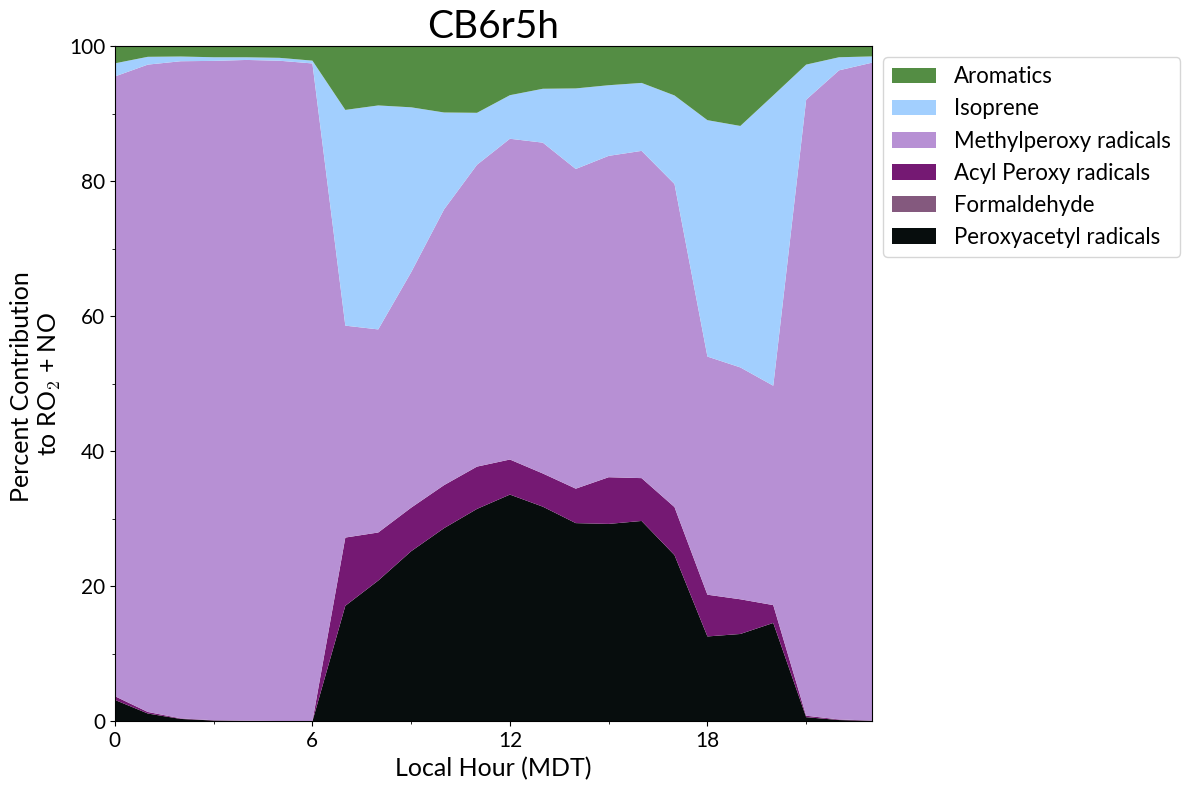

In [173]:
hour_range = np.arange(0,24,1)

fix, ax = plt.subplots(figsize=(12,8))

plt.stackplot(hour_range, *frac_contribution_stack_cb6r5h[::-1], colors=df_cb6r5h_precursor_sum_rearranged['colors'][::-1], labels=df_cb6r5h_precursor_sum_rearranged.index[::-1])
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], loc='upper left', bbox_to_anchor=(1,1))

plt.margins(x=0, y=0)
ax.xaxis.set_minor_locator(MultipleLocator(3))
ax.xaxis.set_major_locator(MultipleLocator(6))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.yaxis.set_major_locator(MultipleLocator(20))

plt.xlabel('Local Hour (MDT)')
plt.ylabel('Percent Contribution \nto RO$_2$ + NO')
plt.title('CB6r5h')
plt.tight_layout()
plt.savefig(dirpath + 'Plotting/For_F0AM_runs/plots/voc_precursor_ro2_no_CB6r5h.png', dpi =150, bbox_inches='tight')
plt.show()